In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.environ["HF_HOME"] = "/content/drive/MyDrive/hf_cache"
os.makedirs(os.environ["HF_HOME"], exist_ok=True)

In [3]:
# ── Install required packages ────────────────────────────────────────────────
import subprocess, sys
for pkg in ["rouge_score", "evaluate", "gradio", "sentencepiece",
            "datasets", "ipywidgets"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)
print("All packages installed.")

All packages installed.


In [4]:
import os, ast, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from tqdm import tqdm

tqdm.pandas()
warnings.filterwarnings("ignore")

import torch
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast   # bfloat16 autocast — no GradScaler needed on A100
from torch.optim import AdamW
import evaluate as evaluate_lib
from transformers import (
    T5ForConditionalGeneration, T5Tokenizer,
    DataCollatorForSeq2Seq,
    get_cosine_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

CSV_PATH       = "/content/drive/MyDrive/spells_master.csv"
MODEL_NAME     = "t5-base"
OUTPUT_DIR     = "/content/drive/MyDrive/GenAiProj/spellforge_vFINAL"
PLOT_DIR       = "/content/drive/MyDrive/GenAiProj/plots"
EPOCHS         = 25
LR             = 2e-4
MAX_IN         = 128
MAX_OUT        = 512
MIN_GEN_TOKENS = 60
LENGTH_PENALTY = 1.3
VAL_SPLIT      = 0.1
SEED           = 42
PATIENCE       = 4
LABEL_SMOOTH   = 0.1


os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,   exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))
    print(f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB VRAM")

cuda
NVIDIA A100-SXM4-40GB
42.4 GB VRAM


In [5]:
# load + final clean of spells_master.csv
def parse_list_col(x):
    if pd.isna(x) or x == "": return []
    if isinstance(x, list):   return x
    try:    return ast.literal_eval(x)
    except: return [s.strip() for s in str(x).split(",") if s.strip()]

def clean(s):
    if not isinstance(s, str): return ""
    s = re.sub(r"\{@\w+\s([^}]+)\}", r"\1", s)
    s = re.sub(r"\{@\w+\}",          "",    s)
    s = re.sub(r"\|[A-Z]{2,}[^|\s]*","",    s)
    s = re.sub(r"\[&\d+;&\d+\]",     "",    s)
    s = re.sub(r"\|bestiary[^*\n]*", "",    s)
    s = re.sub(r"\|[^|}\s]{1,30}",   "",    s)
    return re.sub(r"\s+", " ", s).strip()

df = pd.read_csv(CSV_PATH)

for col in ["classes","subclasses"]:
    df[col] = df[col].apply(parse_list_col)

STR_COLS  = ["desc","higher_levels","material_desc","damage_type","dc_type",
             "attack_type","school","cast_time","range","duration","source"]
BOOL_COLS = ["verbal","somatic","material","concentration","ritual"]

for col in STR_COLS:
    df[col] = df[col].fillna("").apply(clean)
for col in BOOL_COLS:
    df[col] = df[col].apply(lambda x:
        bool(x) if isinstance(x, bool)
        else str(x).strip().lower() in ("true","yes","1","t"))

df["name"]  = df["name"].fillna("").apply(clean)
df["level"] = pd.to_numeric(df["level"], errors="coerce").fillna(0).astype(int)
df = df[df["name"].str.strip() != ""].reset_index(drop=True)
df = df[df["desc"].str.len()   >  40].reset_index(drop=True)
df["cast_time"] = df["cast_time"].apply(lambda x: x if len(x) < 40 else "")

print(f"shape: {df.shape}")
print(f"schools: {sorted(df['school'].unique().tolist())}")

# quick token length report to sanity-check MAX_OUT
_tc = T5Tokenizer.from_pretrained(MODEL_NAME)
df["desc_tokens"] = df["desc"].apply(lambda x: len(_tc(x)["input_ids"]))
print(df["desc_tokens"].describe().to_string())
print(f"truncated at 300: {(df['desc_tokens']>300).sum()} ({(df['desc_tokens']>300).mean()*100:.1f}%)")
df.head(3)

shape: (1333, 20)
schools: ['Abjuration', 'Conjuration', 'Divination', 'Enchantment', 'Evocation', 'Illusion', 'Necromancy', 'Transmutation']


count    1333.000000
mean      162.237059
std       109.737782
min        12.000000
25%        89.000000
50%       137.000000
75%       203.000000
max       917.000000
truncated at 300: 120 (9.0%)


,name,desc,higher_levels,level,school,classes,subclasses,cast_time,range,duration,...,somatic,material,material_desc,concentration,ritual,damage_type,dc_type,attack_type,source,desc_tokens
0,Prismatic Wall,"A shimmering, multicolored plane of light form...",,9,Abjuration,[Wizard],[],1 action,60 feet,10 minutes,...,True,False,,False,False,,,,wotc-srd,917
1,Symbol,"When you cast this spell, you inscribe a harmf...",,7,Abjuration,"[Bard, Cleric, Wizard]",[],1 minute,Touch,Until dispelled or triggered,...,True,True,"Mercury, phosphorus, and powdered diamond and ...",False,False,,,,wotc-srd,859
2,Teleport,This spell instantly transports you and up to ...,,7,Conjuration,"[Bard, Sorcerer, Wizard]",[],1 action,10 feet,Instantaneous,...,False,False,,False,False,,,,wotc-srd,757


In [ ]:
def infer_type(row):
    desc = (row.get("desc") or "").lower()
    rng  = (row.get("range") or "").lower().strip()
    dur  = (row.get("duration") or "").lower()
    has_aoe    = any(p in desc for p in ["-foot radius","radius sphere"," cone"," cube"," cylinder","line of "])
    is_instant = "instantaneous" in dur
    is_self    = rng in ("self","")
    is_touch   = rng == "touch"
    has_damage = bool(str(row.get("damage_type","")).strip())
    is_conc    = bool(row.get("concentration", False))
    if has_aoe:                                   return "aoe"
    if is_self and is_instant and not has_damage: return "teleport"
    if is_touch and not has_damage:               return "touch"
    if is_conc  and not has_damage:               return "concentration"
    if has_damage and not has_aoe:                return "single_target"
    if bool(row.get("ritual", False)):            return "ritual"
    return "utility"

def build_attr(row):
    parts = [f"level: {row['level']}"]
    if row["school"]:        parts.append(f"school: {row['school']}")
    if row["cast_time"]:     parts.append(f"cast_time: {row['cast_time']}")
    if row["range"]:         parts.append(f"range: {row['range']}")
    if row["duration"]:      parts.append(f"duration: {row['duration']}")
    comps = [c for c,f in [("V",row["verbal"]),("S",row["somatic"]),("M",row["material"])] if f]
    if comps:                parts.append(f"components: {', '.join(comps)}")
    if row["classes"]:       parts.append(f"classes: {', '.join(row['classes'])}")
    if row["damage_type"]:   parts.append(f"damage: {row['damage_type']}")
    if row["dc_type"]:       parts.append(f"saving_throw: {row['dc_type']}")
    if row["concentration"]: parts.append("concentration: yes")
    if row["ritual"]:        parts.append("ritual: yes")
    if row["material_desc"]: parts.append(f"material: {row['material_desc']}")
    return " | ".join(parts)

SWAPS = [
    # verb replacements
    (r"\bstreaks toward\b",                    "flies at"),
    (r"\bdealing\b",                           "inflicting"),
    (r"\bon a hit\b",                          "upon striking"),
    (r"\byou hurl\b",                          "you fling"),
    (r"\bbright streak\b",                     "luminous bolt"),
    (r"\byou conjure\b",                       "you summon"),
    (r"\byou channel\b",                       "you pour"),
    (r"\byou weave\b",                         "you twist"),
    # noun / phrase replacements
    (r"\bsaving throw\b",                      "resistance check"),
    (r"\bcreature you can see\b",              "visible target"),
    (r"\bwithin range\b",                      "in range"),
    (r"\bthe ground\b",                        "the earth"),
    (r"\bfor the duration\b",                  "while the magic holds"),
    (r"\ba point of your choice\b",            "a place you designate"),
    # damage phrasing
    (r"\btakes \d+d\d+ (\w+) damage\b",   r"suffers \1 damage"),
    (r"\bon a failed save\b",                  "should they fail"),
    (r"\bon a successful save\b",              "if they succeed"),
    # opening-sentence variety
    (r"^You create a (\d+-foot)",               r"A \1"),
    (r"^You touch a willing creature",            "Reaching out, you touch a creature"),
    (r"^You unleash a",                           "You loose a"),
    (r"^You conjure a cloud",                     "A billowing cloud coalesces"),
    (r"^You summon a (\w+) spirit",             r"A \1 spirit answers your call"),
    # sphere/area boilerplate
    (r"\bcreature in the (sphere|area|cube)\b","creature caught within"),
    (r"\bthe sphere spreads around corners\b", "it creeps around corners"),
    (r"\bcentered on a point you can see\b",   "at a point you choose"),
    (r"\bcentered on a point within range\b",  "at a chosen point"),
    (r"\bfills the area\b",                    "floods the space"),
]

def augment_desc(desc):
    for pat, rep in SWAPS:
        if re.search(pat, desc, re.I):
            return re.sub(pat, rep, desc, count=1, flags=re.I)
    return desc

SCHOOLS      = sorted([s for s in df["school"].unique().tolist() if s])
ALL_CLASSES  = sorted(set(c for cs in df["classes"] for c in cs))
DAMAGE_TYPES = sorted(df[df["damage_type"]!=""]["damage_type"].unique().tolist())
DC_TYPES     = sorted(df[df["dc_type"]!=""]["dc_type"].unique().tolist())

df["spell_type"] = df.apply(infer_type, axis=1)
print(df["spell_type"].value_counts().to_string())

spell_type
utility          354
concentration    298
aoe              248
touch            243
single_target     94
ritual            51
teleport          45


In [ ]:
# ── Data augmentation helpers + multi-task example builder ───────────────────
import random

def sent_dropout(text, p=0.15):
    """Randomly drop sentences from description for regularization."""
    sentences = text.split(". ")
    if len(sentences) <= 1:
        return text
    kept = [s for s in sentences if random.random() > p]
    return ". ".join(kept) if kept else text

def boilerplate_dropout(text, p=0.5):
    """Randomly drop common D&D boilerplate phrases."""
    BOILERPLATE = [
        "at the start of each of its turns",
        "on a failed save",
        "on a successful save",
        "for the duration",
        "until the spell ends",
        "as a bonus action",
    ]
    for phrase in BOILERPLATE:
        if phrase in text.lower() and random.random() < p:
            text = text.replace(phrase, "")
    return text.strip()

rows = []
for _, row in df.iterrows():
    attr = build_attr(row)
    desc = row["desc"]
    name = row["name"]
    hl   = row["higher_levels"]

    if attr and desc:
        rows.append({"input": f"generate description: {attr}", "output": desc,            "task": "a2d"})
        aug = augment_desc(desc)
        if aug != desc:
            rows.append({"input": f"generate description: {attr}", "output": aug,         "task": "a2d"})

    # task: name → description
    if name and desc:
        rows.append({"input": f"describe spell: {name}",            "output": desc,       "task": "n2d"})

    # task: name + hints → description
    if name and attr and desc:
        rows.append({"input": f"describe spell: {name} | {attr}",   "output": desc,       "task": "na2d"})

    # task: description → name
    if desc and name:
        rows.append({"input": f"generate name: {desc}",             "output": name,       "task": "d2n"})

    # task: attributes → name
    if attr and name:
        rows.append({"input": f"name this spell: {attr}",           "output": name,       "task": "a2n"})

    # task: upcast text
    if name and hl:
        rows.append({"input": f"upcast: {name} | {attr}",           "output": hl,         "task": "upcast"})

    # task: predict saving throw
    if desc and row["dc_type"]:
        rows.append({"input": f"saving throw: {desc}",              "output": row["dc_type"],   "task": "pred_dc"})

    # task: predict school
    if desc and row["school"]:
        rows.append({"input": f"school of magic: {desc}",           "output": row["school"],    "task": "pred_school"})

    # task: predict damage type
    if desc and row["damage_type"]:
        rows.append({"input": f"damage type: {desc}",               "output": row["damage_type"], "task": "pred_dmg"})

ex_df = pd.DataFrame(rows).dropna().reset_index(drop=True)
print(f"total examples: {len(ex_df)}")
print(ex_df["task"].value_counts().to_string())


total examples: 9865
task
a2d            2368
n2d            1333
na2d           1333
d2n            1333
a2n            1333
pred_school    1333
upcast          517
pred_dc         163
pred_dmg        152


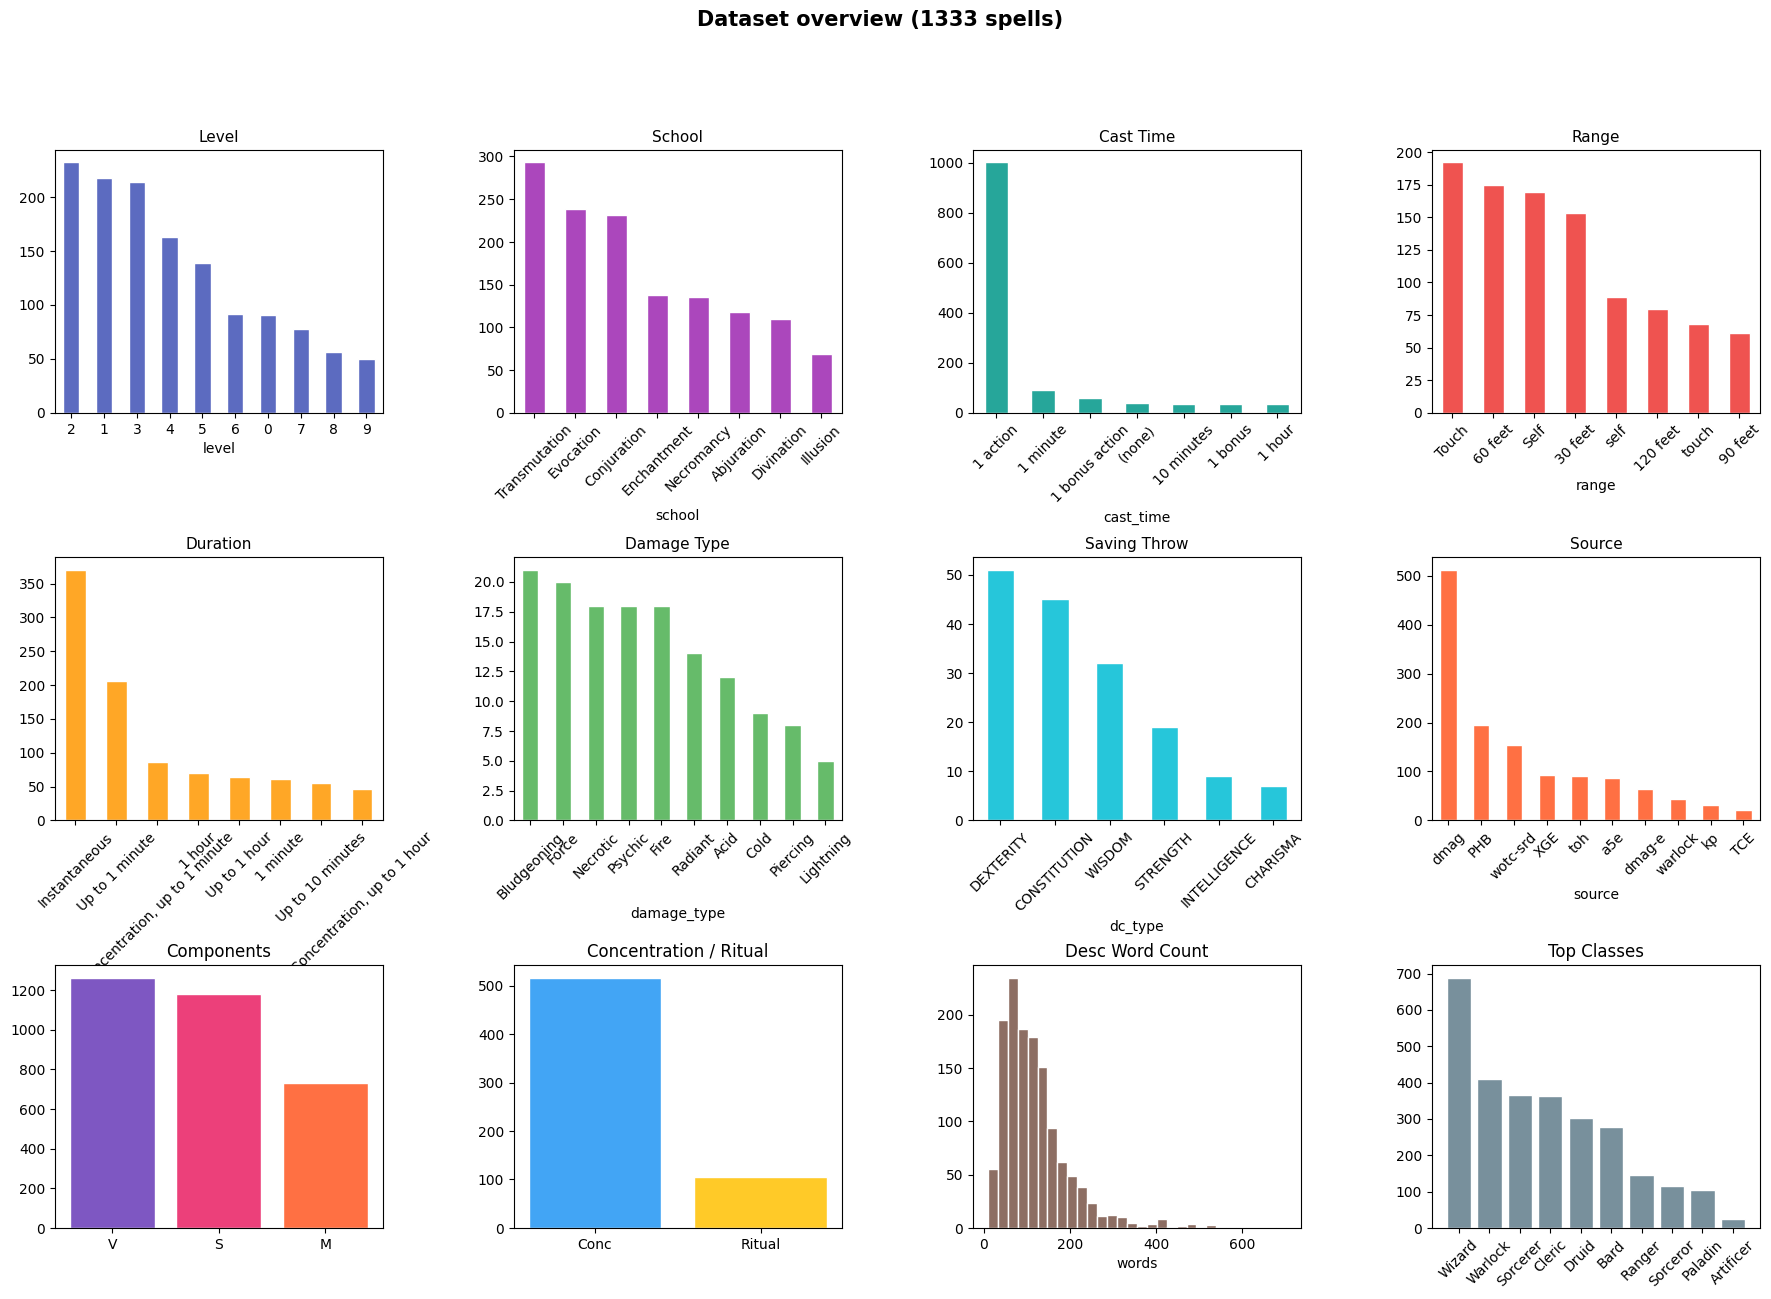

In [ ]:
# EDA — quick look at the dataset
df["desc_wc"] = df["desc"].str.split().str.len()

fig = plt.figure(figsize=(22, 14))
fig.suptitle(f"Dataset overview ({len(df)} spells)", fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

def barplot(ax, series, title, color, top=None, rot=45):
    vc = series.value_counts()
    if top: vc = vc.head(top)
    vc.plot(kind="bar", ax=ax, color=color, edgecolor="white")
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=rot)

barplot(fig.add_subplot(gs[0,0]), df["level"],   "Level",   "#5C6BC0", rot=0)
barplot(fig.add_subplot(gs[0,1]), df["school"],  "School",  "#AB47BC")
barplot(fig.add_subplot(gs[0,2]), df["cast_time"].replace("","(none)"), "Cast Time","#26A69A", top=7)
barplot(fig.add_subplot(gs[0,3]), df["range"],   "Range",   "#EF5350", top=8)
barplot(fig.add_subplot(gs[1,0]), df["duration"],"Duration","#FFA726", top=8)
barplot(fig.add_subplot(gs[1,1]), df[df["damage_type"]!=""]["damage_type"],"Damage Type","#66BB6A", top=10)
barplot(fig.add_subplot(gs[1,2]), df[df["dc_type"]!=""]["dc_type"],"Saving Throw","#26C6DA")
barplot(fig.add_subplot(gs[1,3]), df["source"],  "Source",  "#FF7043", top=10)

ax = fig.add_subplot(gs[2,0])
ax.bar(["V","S","M"],
       [df["verbal"].sum(), df["somatic"].sum(), df["material"].sum()],
       color=["#7E57C2","#EC407A","#FF7043"], edgecolor="white")
ax.set_title("Components")

ax = fig.add_subplot(gs[2,1])
ax.bar(["Conc","Ritual"], [df["concentration"].sum(), df["ritual"].sum()],
       color=["#42A5F5","#FFCA28"], edgecolor="white")
ax.set_title("Concentration / Ritual")

ax = fig.add_subplot(gs[2,2])
ax.hist(df["desc_wc"], bins=30, color="#8D6E63", edgecolor="white")
ax.set_title("Desc Word Count"); ax.set_xlabel("words")

ax = fig.add_subplot(gs[2,3])
cc = Counter(c for cs in df["classes"] for c in cs).most_common(10)
if cc: ax.bar(*zip(*cc), color="#78909C", edgecolor="white")
ax.set_title("Top Classes"); ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/eda.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
np.random.seed(SEED)

_BOILERPLATE = [
    # save/damage templates
    "half as much damage on a successful",
    "or half as much damage",
    "half damage on a successful saving throw",
    "takes half as much damage",
    # turn/duration filler
    "on each of its turns until the spell ends",
    "at the end of each of its turns",
    "at the start of each of its turns",
    "until the spell ends",
    "for the duration",
    "while the spell is active",
    # area/geometry boilerplate
    "spreads around corners",
    "the sphere spreads around corners",
    "centered on a point you can see",
    "centered on a point within range",
    "within the area of effect",
    "fills the area",
    # condition boilerplate
    "ending the effect on itself on a success",
    "ending the effect on a success",
    "on a failed save",
    "on a successful save",
    # sight/light filler
    "vision and light",
    "can see normally in darkness",
    "bright light in a",
    "dim light for an additional",
    # concentration line
    "requires concentration",
    "maintaining concentration",
    # generic action filler
    "as a bonus action on each of your turns",
    "as a bonus action",
    "you can use your action to",
    "you can use a bonus action to",
]

def sent_dropout(text, p=0.30):
    sents = [s for s in re.split(r'(?<=[.!?])\s+', text.strip()) if s.strip()]
    if len(sents) <= 3:
        return text
    if np.random.random() < p:
        return " ".join(sents[:-1])
    return text

def boilerplate_dropout(text, p=0.55):
    sents = [s for s in re.split(r'(?<=[.!?])\s+', text.strip()) if s.strip()]
    if len(sents) <= 2:
        return text
    result = []
    for sent in sents:
        sl = sent.lower()
        is_boiler = any(b in sl for b in _BOILERPLATE)
        if is_boiler and np.random.random() < p:
            continue
        result.append(sent)
    return " ".join(result) if result else text

examples = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="building examples"):
    full = build_attr(row)
    aug  = augment_desc(row["desc"])

    examples.append({"input": f"generate description: {full}",   "output": row["desc"],  "task": "a2d"})
    examples.append({"input": f"generate name: {row['desc']}",   "output": row["name"],  "task": "d2n"})
    if aug != row["desc"]:
        examples.append({"input": f"generate name: {aug}",       "output": row["name"],  "task": "d2n_aug"})
    examples.append({"input": f"describe spell: {row['name']}",  "output": row["desc"],  "task": "n2d"})
    examples.append({
        "input":  f"describe spell: {row['name']} | school: {row['school']} | level: {row['level']}",
        "output": row["desc"], "task": "na2d",
    })
    examples.append({"input": f"name this spell: {full}",        "output": row["name"],  "task": "a2n"})
    if row["higher_levels"].strip():
        examples.append({
            "input":  f"upcast: {row['name']} | {full}",
            "output": row["higher_levels"], "task": "upcast",
        })
    if row["dc_type"]:
        examples.append({"input": f"saving throw: {row['desc']}",    "output": row["dc_type"],     "task": "pred_dc"})
    if row["school"]:
        examples.append({"input": f"school of magic: {row['desc']}","output": row["school"],      "task": "pred_school"})
    if row["damage_type"]:
        examples.append({"input": f"damage type: {row['desc']}",     "output": row["damage_type"], "task": "pred_dmg"})

ex_df   = pd.DataFrame(examples)
aug_cap = ex_df[ex_df["task"] == "d2n_aug"].sample(min(500, (ex_df["task"]=="d2n_aug").sum()), random_state=SEED)
ex_df   = pd.concat([ex_df[ex_df["task"] != "d2n_aug"], aug_cap]).reset_index(drop=True)

print(f"total examples: {len(ex_df)}")
print(ex_df["task"].value_counts().to_string())

building examples: 100%|██████████| 1333/1333 [00:00<00:00, 3721.04it/s]

total examples: 9330
task
a2d            1333
d2n            1333
n2d            1333
na2d           1333
a2n            1333
pred_school    1333
upcast          517
d2n_aug         500
pred_dc         163
pred_dmg        152


In [10]:
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

DESC_TASKS = {"a2d", "n2d", "na2d"}

class SpellDataset(Dataset):
    def __init__(self, data, training=False):
        self.data     = data.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        output = row["output"]
        if self.training and row["task"] in DESC_TASKS:
            output = sent_dropout(output)
            output = boilerplate_dropout(output)
        enc = tokenizer(row["input"],       max_length=MAX_IN,  truncation=True)
        lab = tokenizer(text_target=output, max_length=MAX_OUT, truncation=True)
        return {
            "input_ids":      enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "labels":         lab["input_ids"],
        }

train_df, val_df = train_test_split(
    ex_df, test_size=VAL_SPLIT, random_state=SEED, stratify=ex_df["task"]
)
train_ds = SpellDataset(train_df, training=True)
val_ds   = SpellDataset(val_df,   training=False)

print(f"train: {len(train_df)}  val: {len(val_df)}")
# collator and dataloaders built after model load (next cell)

train: 8397  val: 933


In [11]:
import gc, os

for _v in ["model", "optimizer", "scheduler"]:
    if _v in globals():
        del globals()[_v]
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"GPU free before load: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved())/1e9:.1f} GB")

RESUME_FROM = OUTPUT_DIR
if os.path.exists(os.path.join(RESUME_FROM, "model.safetensors")):
    model = T5ForConditionalGeneration.from_pretrained(
        RESUME_FROM, torch_dtype=torch.bfloat16, low_cpu_mem_usage=True
    ).to(device)
    print(f"resumed from {RESUME_FROM}")
else:
    model = T5ForConditionalGeneration.from_pretrained(
        MODEL_NAME, torch_dtype=torch.bfloat16, low_cpu_mem_usage=True,
        dropout_rate=0.15,
    ).to(device)
    print("training from scratch")
model.gradient_checkpointing_enable()
print(f"{sum(p.numel() for p in model.parameters())/1e6:.0f}M params")
print(f"{torch.cuda.memory_allocated()/1e9:.2f} GB used after load")

no_decay = {"bias", "LayerNorm.weight", "layer_norm.weight", "shared.weight", "embed_tokens.weight"}
def make_optimizer():
    return AdamW([
        {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
         "weight_decay": 0.01},
        {"params": [p for n, p in model.named_parameters() if     any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ], lr=LR, fused=True)

optimizer = make_optimizer()

def find_max_batch_size(model, optimizer, tokenizer, device, min_bs=4, max_bs=512):
    dummy_in  = "generate description: level: 3 | school: Evocation | cast_time: 1 action | range: 150 feet | duration: Instantaneous | components: V, S, M | damage: Fire | saving_throw: DEX | classes: Sorcerer, Wizard"
    dummy_out = ("A bright streak flashes from your pointing finger to a point you choose within range "
                 "and then blossoms with a low roar into an explosion of flame. Each creature in a "
                 "20-foot-radius sphere centered on that point must make a Dexterity saving throw. "
                 "A target takes 8d6 fire damage on a failed save, or half as much damage on a "
                 "successful one. The fire spreads around corners. It ignites flammable objects in "
                 "the area that aren't being worn or carried.")

    def label_smooth_probe(logits, labels):
        vocab = logits.size(-1)
        lp    = torch.nn.functional.log_softmax(logits, dim=-1)
        sl    = -lp.sum(dim=-1) / vocab
        hl    = torch.nn.functional.nll_loss(
            lp.view(-1, vocab), labels.view(-1), ignore_index=-100, reduction="none"
        ).view(labels.shape)
        mask  = labels.ne(-100).float()
        return 0.9 * (hl * mask).sum() / mask.sum() + 0.1 * (sl * mask).sum() / mask.sum()

    def probe(bs):
        torch.cuda.empty_cache(); gc.collect()
        try:
            enc = tokenizer(
                [dummy_in] * bs, max_length=MAX_IN, truncation=True,
                padding=True, return_tensors="pt",
            ).to(device)
            lab = tokenizer(
                [dummy_out] * bs, max_length=MAX_OUT, truncation=True,
                padding=True, return_tensors="pt",
            )
            labels = lab["input_ids"].clone().to(device)
            labels[labels == tokenizer.pad_token_id] = -100
            optimizer.zero_grad(set_to_none=True)
            with autocast(dtype=torch.bfloat16):
                out  = model(**enc, labels=labels)
                loss = label_smooth_probe(out.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            torch.cuda.empty_cache(); gc.collect()
            print(f"  bs={bs:4d}  ok")
            return True
        except torch.cuda.OutOfMemoryError:
            optimizer.zero_grad(set_to_none=True)
            torch.cuda.empty_cache(); gc.collect()
            print(f"  bs={bs:4d}  OOM")
            return False

    lo, hi = min_bs, min_bs
    while hi <= max_bs and probe(hi):
        lo = hi
        hi = min(hi * 2, max_bs + 1)

    if lo == min_bs and not probe(min_bs):
        print("min_bs OOMs — free memory first")
        return min_bs

    best = lo
    low, high = lo + 1, hi - 1
    while low <= high:
        mid = (low + high) // 2
        if probe(mid): best = mid; low  = mid + 1
        else:          high = mid - 1

    torch.cuda.empty_cache(); gc.collect()
    return best

print(f"\nGPU free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved())/1e9:.1f} GB")
print("probing (includes optimizer step)...")
_max_bs = find_max_batch_size(model, optimizer, tokenizer, device, min_bs=4, max_bs=512)

TRAIN_BATCH_SIZE = max(4, int(_max_bs * 0.50))
VAL_BATCH_SIZE   = max(4, int(_max_bs * 0.60))
print(f"\nmax fit : {_max_bs}")
print(f"train   : {TRAIN_BATCH_SIZE}")
print(f"val     : {VAL_BATCH_SIZE}")

optimizer = make_optimizer()

collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True,
                                  pad_to_multiple_of=8, return_tensors="pt")

train_dl = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, collate_fn=collator)
val_dl   = DataLoader(val_ds,   batch_size=VAL_BATCH_SIZE,   shuffle=False,
                      num_workers=2, pin_memory=True, collate_fn=collator)
print(f"train batches: {len(train_dl)}  val batches: {len(val_dl)}")

total_steps  = len(train_dl) * EPOCHS
scheduler    = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
rouge_metric = evaluate_lib.load("rouge")

def label_smoothed_loss(logits, labels, smoothing=LABEL_SMOOTH):
    vocab  = logits.size(-1)
    mask   = labels.ne(-100).float()
    pos_w  = torch.ones_like(mask)
    pos_w[:, :60] = 3.0
    w      = mask * pos_w
    hl_sum = torch.zeros(1, device=logits.device, dtype=torch.float32)
    sl_sum = torch.zeros(1, device=logits.device, dtype=torch.float32)
    for i in range(logits.size(0)):
        lp_i    = torch.nn.functional.log_softmax(logits[i].float(), dim=-1)
        sl_sum += -(lp_i.sum(dim=-1) * w[i]).sum() / vocab
        hl_sum += torch.nn.functional.nll_loss(
            lp_i, labels[i], ignore_index=-100, reduction="none"
        ).mul(w[i]).sum()
    w_sum = w.sum()
    return (1 - smoothing) * hl_sum / w_sum + smoothing * sl_sum / w_sum

print("ready")


GPU free before load: 42.4 GB


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

training from scratch
223M params
0.45 GB used after load

GPU free: 41.9 GB
probing (includes optimizer step)...
  bs=   4  ok
  bs=   8  ok
  bs=  16  ok
  bs=  32  ok
  bs=  64  ok
  bs= 128  ok
  bs= 256  OOM
  bs= 192  ok
  bs= 224  ok
  bs= 240  OOM
  bs= 232  OOM
  bs= 228  ok
  bs= 230  OOM
  bs= 229  OOM

max fit : 228
train   : 114
val     : 136
train batches: 74  val batches: 7
ready


In [12]:
def generate(prompt, max_new=320, min_new=None, num_beams=4,
             temperature=1.0, top_p=0.95, repetition_penalty=1.3,
             do_sample=None):
    if do_sample is None: do_sample = temperature > 1.0
    if min_new   is None: min_new   = MIN_GEN_TOKENS
    model.eval()
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_IN).to(device)
    with torch.no_grad():
        ids = model.generate(
            **enc,
            max_new_tokens       = max_new,
            min_new_tokens       = min_new,
            length_penalty       = LENGTH_PENALTY,
            num_beams            = num_beams,
            early_stopping       = True,
            no_repeat_ngram_size = 3,
            repetition_penalty   = repetition_penalty,
            temperature          = temperature,
            do_sample            = do_sample,
            top_p                = top_p if do_sample else 1.0,
        )
    return tokenizer.decode(ids[0], skip_special_tokens=True)

PROBES = [
    {"label": "Poison Gas + WIS Save",
     "prompt": "generate description: level: 4 | school: Conjuration | cast_time: 1 action | range: 60 feet | duration: Up to 1 minute | components: V, S, M | damage: Poison | saving_throw: WIS | concentration: yes",
     "max_new": 280},
    {"label": "Chain Lightning",
     "prompt": "generate description: level: 6 | school: Evocation | cast_time: 1 action | range: 150 feet | damage: Lightning | saving_throw: DEX | classes: Sorcerer, Wizard",
     "max_new": 280},
    {"label": "Nature Curse + Ritual",
     "prompt": "generate description: level: 3 | school: Enchantment | cast_time: 1 minute | range: Touch | duration: 24 hours | saving_throw: WIS | ritual: yes | classes: Druid",
     "max_new": 280},
    {"label": "Void Miasma (novel spell name)",
     "prompt": "describe spell: Void Miasma | school: Illusion | level: 5",
     "max_new": 280},
    {"label": "Name for toxic fog",
     "prompt": "name this spell: level: 4 | school: Conjuration | damage: Poison | saving_throw: WIS | concentration: yes",
     "max_new": 20},
    {"label": "Fireball (real spell)",
     "prompt": "describe spell: Fireball",
     "max_new": 280},
    {"label": "Misty Step (real spell)",
     "prompt": "describe spell: Misty Step",
     "max_new": 280},
    {"label": "Ashen Pyre (Fire + Necromancy mix)",
     "prompt": "describe spell: Ashen Pyre | school: Necromancy | level: 5",
     "max_new": 280},
    {"label": "Cantrip + Concentration + WIS",
     "prompt": "generate description: level: 0 | school: Enchantment | cast_time: 1 action | range: 30 feet | duration: Up to 1 minute | saving_throw: WIS | concentration: yes | classes: Warlock",
     "max_new": 280},
    {"label": "Upcast — Cure Wounds",
     "prompt": "upcast: Cure Wounds | level: 1 | school: Evocation | classes: Cleric, Paladin",
     "max_new": 120},
]

def compute_rouge(mdl, dl, n_batches=30):
    mdl.eval()
    preds, refs = [], []
    with torch.no_grad():
        for i, batch in enumerate(dl):
            if i >= n_batches: break
            ids    = mdl.generate(
                input_ids      = batch["input_ids"].to(device),
                attention_mask = batch["attention_mask"].to(device),
                max_new_tokens = 80, num_beams=2,
            )
            labels = batch["labels"]
            labels = torch.where(labels == -100, torch.tensor(tokenizer.pad_token_id), labels)
            preds += tokenizer.batch_decode(ids,    skip_special_tokens=True)
            refs  += tokenizer.batch_decode(labels, skip_special_tokens=True)
    return rouge_metric.compute(predictions=preds, references=refs, use_stemmer=True)

def print_probes(label):
    print(f"--- {label} ---")
    for p in PROBES:
        out = generate(p["prompt"], max_new=p["max_new"])
        print(f"[{p['label']}]")
        print(f"  in : {p['prompt'][:100]}{'...' if len(p['prompt'])>100 else ''}")
        print(f"  out: {out}")
    print()

print("helpers ready — running baseline probes")
print_probes("before training")

helpers ready — running baseline probes
--- before training ---
[Poison Gas + WIS Save]
  in : generate description: level: 4 | school: Conjuration | cast_time: 1 action | range: 60 feet | durati...
  out: Level: 4 | school: Conjuration | range: 60 feet | duration: Up to 1 minute | components: V, S, M | damage_resistance: Poison | saving_throw: WIS | concentration: yes | target_disposition: Yes | class_name: School of Conjuring | school_of_conjuration: High School | cast_time: 1 action | character_class: Highschool | school's name: HighSchool | school-of-Conjuration| school
[Chain Lightning]
  in : generate description: level: 6 | school: Evocation | cast_time: 1 action | range: 150 feet | damage:...
  out: evocation | school: Evocation | cast_time: 1 action | range: 150 feet | damage: Lightning | saving_throw: DEX | classes: Sorcerer, Wizard | class_names: 'Evocation' | school_id: "Evocation"
[Nature Curse + Ritual]
  in : generate description: level: 3 | school: Enchantment | cast_ti

In [ ]:
best_rouge_l = -1.0
no_improve   = 0
train_hist, val_hist, rouge_hist = [], [], []

for epoch in range(1, EPOCHS + 1):

    # train
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_dl, desc=f"epoch {epoch:02d}/{EPOCHS} [train]", leave=False)
    for batch in pbar:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=torch.bfloat16):
            decoder_input_ids = model._shift_right(labels)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                            decoder_input_ids=decoder_input_ids)
            loss    = label_smoothed_loss(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train = epoch_loss / len(train_dl)
    train_hist.append(avg_train)

    # val loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f"epoch {epoch:02d}/{EPOCHS} [val]  ", leave=False):
            with autocast(dtype=torch.bfloat16):
                _labels = batch["labels"].to(device)
                _dec_ids = model._shift_right(_labels)
                out  = model(input_ids=batch["input_ids"].to(device),
                             attention_mask=batch["attention_mask"].to(device),
                             decoder_input_ids=_dec_ids)
                loss = label_smoothed_loss(out.logits, _labels)
            val_loss += loss.item()
    avg_val = val_loss / len(val_dl)
    val_hist.append(avg_val)

    # rouge (fast, 30 batches)
    scores  = compute_rouge(model, val_dl, n_batches=30)
    rouge_l = scores.get("rougeL", 0.0)
    rouge_hist.append(rouge_l)

    # checkpoint on best ROUGE-L
    saved = ""
    if rouge_l > best_rouge_l:
        best_rouge_l = rouge_l
        no_improve   = 0
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        saved = "  <- saved"
    else:
        no_improve += 1

    print(f"epoch {epoch:02d}/{EPOCHS}  "
          f"train={avg_train:.4f}  val={avg_val:.4f}  "
          f"rouge-L={rouge_l:.4f}  r1={scores.get('rouge1',0):.4f}"
          f"{saved}")

    # probes every 4 epochs — less noise, doesn't break training flow
    if epoch % 4 == 0:
        print_probes(f"epoch {epoch}")

    if no_improve >= PATIENCE:
        print(f"early stop — no rouge-L gain for {PATIENCE} eval rounds")
        break

    torch.cuda.empty_cache()

print(f"best ROUGE-L: {best_rouge_l:.4f}")

epoch 01/25 [train]:   0%|          | 0/74 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 01/25  train=7.2688  val=5.2221  rouge-L=0.0216  r1=0.0236  <- saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 02/25  train=5.0975  val=4.3696  rouge-L=0.1429  r1=0.1618  <- saved


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 04/25  train=4.3420  val=3.9516  rouge-L=0.2134  r1=0.2373  <- saved
--- epoch 4 ---
[Poison Gas + WIS Save]
  in : generate description: level: 4 | school: Conjuration | cast_time: 1 action | range: 60 feet | durati...
  out: When you cast this spell using a spell slot of 3rd level or higher, the damage increases by 1d6 for each slot level above 4th. The damage decreases by 2d8 for every slot level below 4th and 5th. You can use the spell to make a melee spell attack against a creature that you can see within range.
[Chain Lightning]
  in : generate description: level: 6 | school: Evocation | cast_time: 1 action | range: 150 feet | damage:...
  out: When you cast this spell using a spell slot of 6th level or higher, the damage increases by 1d8 for each slot level above 6th. The damage increases to 1d6 for every slot level below 6th and the damage decreases by 1D6 for each Slot level above 7th.
[Nature Curse + Ritual]
  in : generate description: level: 3 | school: Enchantment | 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 05/25  train=4.2148  val=3.8572  rouge-L=0.2205  r1=0.2460  <- saved


epoch 06/25 [train]:  22%|██▏       | 16/74 [00:37<02:09,  2.24s/it, loss=4.1514]

In [ ]:
import os, torch
from transformers import T5ForConditionalGeneration, T5Tokenizer
import gradio as gr

WEIGHTS_DIR = "/content/drive/MyDrive/GenAiProj/spellforge_vFINAL"
MAX_IN      = 128
MIN_TOKENS  = 60
LEN_PENALTY = 1.3

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = T5ForConditionalGeneration.from_pretrained(WEIGHTS_DIR).to(device)
tokenizer = T5Tokenizer.from_pretrained(WEIGHTS_DIR)
model.eval()
print(f"loaded {sum(p.numel() for p in model.parameters())/1e6:.0f}M params from {WEIGHTS_DIR}")


def generate(prompt, max_new=320, min_new=0, num_beams=4,
             temperature=1.0, top_p=0.95, do_sample=False,
             repetition_penalty=1.3):
    if do_sample is None: do_sample = temperature > 1.0
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_IN).to(device)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens       = max_new,
            min_new_tokens       = min_new,
            num_beams            = num_beams,
            length_penalty       = LEN_PENALTY,
            early_stopping       = True,
            no_repeat_ngram_size = 3,
            repetition_penalty   = repetition_penalty,
            temperature          = temperature,
            do_sample            = do_sample,
            top_p                = top_p if do_sample else 1.0,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


def build_attr_ui(level="", school="", cast_time="", range_="", duration="",
                  verbal=False, somatic=False, material=False, classes=None,
                  damage_type="", dc_type="", concentration=False, ritual=False,
                  material_desc=""):
    parts = []
    if level != "":   parts.append(f"level: {level}")
    if school:         parts.append(f"school: {school}")
    if cast_time:      parts.append(f"cast_time: {cast_time}")
    if range_:         parts.append(f"range: {range_}")
    if duration:       parts.append(f"duration: {duration}")
    comps = [c for c, f in [("V", verbal), ("S", somatic), ("M", material)] if f]
    if comps:          parts.append(f"components: {', '.join(comps)}")
    if classes:        parts.append(f"classes: {', '.join(classes)}")
    if damage_type:    parts.append(f"damage: {damage_type}")
    if dc_type:        parts.append(f"saving_throw: {dc_type}")
    if concentration:  parts.append("concentration: yes")
    if ritual:         parts.append("ritual: yes")
    if material_desc:  parts.append(f"material: {material_desc}")
    return " | ".join(parts)


def generate_varied(prompt, noise_scale=0.3, n=4, num_beams=2):
    from transformers.modeling_outputs import BaseModelOutput
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_IN).to(device)
    results = []
    with torch.no_grad():
        encoder_out = model.encoder(**enc)
        for _ in range(n):
            noisy = encoder_out.last_hidden_state + torch.randn_like(encoder_out.last_hidden_state) * noise_scale
            ids = model.generate(
                encoder_outputs=BaseModelOutput(last_hidden_state=noisy),
                attention_mask=enc["attention_mask"],
                max_new_tokens=300, num_beams=num_beams,
                no_repeat_ngram_size=3, repetition_penalty=1.3,
            )
            results.append(tokenizer.decode(ids[0], skip_special_tokens=True))
    return results


def interpolate_spells(prompt_a, prompt_b, alpha=0.5):
    from transformers.modeling_outputs import BaseModelOutput
    def encode(p):
        enc = tokenizer(p, return_tensors="pt", truncation=True,
                        padding="max_length", max_length=MAX_IN).to(device)
        return model.encoder(**enc), enc["attention_mask"]
    out_a, mask_a = encode(prompt_a)
    out_b, mask_b = encode(prompt_b)
    mixed      = alpha * out_a.last_hidden_state + (1 - alpha) * out_b.last_hidden_state
    mixed_mask = (mask_a.bool() | mask_b.bool()).long()
    with torch.no_grad():
        ids = model.generate(
            encoder_outputs=BaseModelOutput(last_hidden_state=mixed),
            attention_mask=mixed_mask,
            max_new_tokens=300, num_beams=2,
            no_repeat_ngram_size=3, repetition_penalty=1.3,
        )
    return tokenizer.decode(ids[0], skip_special_tokens=True)


def h_a2d(school, level, cast_time, range_, duration, verbal, somatic,
          material, classes, damage_type, dc_type, concentration, ritual,
          material_desc, nb, temp, topp, rep_pen):
    p = build_attr_ui(level=level, school=school, cast_time=cast_time, range_=range_,
                      duration=duration, verbal=verbal, somatic=somatic, material=material,
                      classes=classes or [], damage_type=damage_type, dc_type=dc_type,
                      concentration=concentration, ritual=ritual, material_desc=material_desc)
    if not p:
        return "fill in at least one field first"
    return generate(f"generate description: {p}", min_new=MIN_TOKENS,
                    num_beams=int(nb), temperature=temp, top_p=topp,
                    do_sample=temp > 1.0, repetition_penalty=rep_pen)


def h_d2n(desc, nb, temp, topp, rep_pen):
    if not desc.strip():
        return "enter a description first"
    return generate(
        f"generate name: {desc}",
        max_new=20, min_new=1,
        num_beams=1, temperature=max(temp, 1.2), top_p=topp,
        do_sample=True, repetition_penalty=rep_pen
    )


def h_n2d(name, school, level, nb, temp, topp, rep_pen):
    if not name.strip():
        return "enter a spell name"
    parts = [name.strip()]
    if school:        parts.append(f"school: {school}")
    if level != "":   parts.append(f"level: {level}")
    return generate(f"describe spell: {' | '.join(parts)}", min_new=MIN_TOKENS,
                    num_beams=int(nb), temperature=temp, top_p=topp,
                    do_sample=temp > 1.0, repetition_penalty=rep_pen)


def h_a2n(school, level, cast_time, range_, duration, verbal, somatic,
          material, classes, damage_type, dc_type, concentration, ritual,
          material_desc, nb, temp, topp, rep_pen):
    p = build_attr_ui(level=level, school=school, cast_time=cast_time, range_=range_,
                      duration=duration, verbal=verbal, somatic=somatic, material=material,
                      classes=classes or [], damage_type=damage_type, dc_type=dc_type,
                      concentration=concentration, ritual=ritual, material_desc=material_desc)
    if not p:
        return "fill in at least one field first"
    return generate(f"name this spell: {p}", max_new=20, min_new=1,
                    num_beams=1, temperature=max(temp, 1.2), top_p=topp,
                    do_sample=True, repetition_penalty=rep_pen)


def h_forge(school, level, cast_time, range_, duration, verbal, somatic,
            material, classes, damage_type, dc_type, concentration, ritual,
            material_desc, nb, temp, topp, rep_pen):
    p = build_attr_ui(level=level, school=school, cast_time=cast_time, range_=range_,
                      duration=duration, verbal=verbal, somatic=somatic, material=material,
                      classes=classes or [], damage_type=damage_type, dc_type=dc_type,
                      concentration=concentration, ritual=ritual, material_desc=material_desc)
    if not p:
        return "fill in at least one field first", ""
    name = generate(f"name this spell: {p}", max_new=20, min_new=1,
                    num_beams=1, temperature=max(temp, 1.2), top_p=topp,
                    do_sample=True, repetition_penalty=rep_pen)
    desc = generate(f"generate description: {p}", min_new=MIN_TOKENS,
                    num_beams=int(nb), temperature=temp, top_p=topp,
                    do_sample=temp > 1.0, repetition_penalty=rep_pen)
    return name, desc


def h_upcast(name, school, level, nb, temp, topp, rep_pen):
    if not name.strip():
        return "enter a spell name"
    attrs = build_attr_ui(school=school, level=level or "")
    p = name.strip() + (" | " + attrs if attrs else "")
    return generate(f"upcast: {p}", max_new=200, min_new=30,
                    num_beams=int(nb), temperature=temp, top_p=topp,
                    do_sample=temp > 1.0, repetition_penalty=rep_pen)


def h_pred(desc, nb, temp, topp, rep_pen):
    if not desc.strip():
        return "", "", ""
    dc     = generate(f"saving throw: {desc}",    max_new=8, min_new=1, num_beams=int(nb), temperature=temp, top_p=topp, repetition_penalty=rep_pen)
    school = generate(f"school of magic: {desc}", max_new=8, min_new=1, num_beams=int(nb), temperature=temp, top_p=topp, repetition_penalty=rep_pen)
    dmg    = generate(f"damage type: {desc}",     max_new=8, min_new=1, num_beams=int(nb), temperature=temp, top_p=topp, repetition_penalty=rep_pen)
    return dc, school, dmg


def h_explore_noise(school, level, cast_time, range_, duration, verbal, somatic,
                    material, classes, damage_type, dc_type, concentration, ritual,
                    material_desc, noise_scale, n):
    p = build_attr_ui(level=level, school=school, cast_time=cast_time, range_=range_,
                      duration=duration, verbal=verbal, somatic=somatic, material=material,
                      classes=classes or [], damage_type=damage_type, dc_type=dc_type,
                      concentration=concentration, ritual=ritual, material_desc=material_desc)
    if not p:
        return ["fill in at least one field first"] * 4
    results = generate_varied(f"generate description: {p}", noise_scale=noise_scale, n=int(n))
    while len(results) < 4:
        results.append("")
    return results[:4]


def h_noise_sweep(school, level, cast_time, range_, duration, verbal, somatic,
                  material, classes, damage_type, dc_type, concentration, ritual,
                  material_desc):
    p = build_attr_ui(level=level, school=school, cast_time=cast_time, range_=range_,
                      duration=duration, verbal=verbal, somatic=somatic, material=material,
                      classes=classes or [], damage_type=damage_type, dc_type=dc_type,
                      concentration=concentration, ritual=ritual, material_desc=material_desc)
    if not p:
        return ["fill in at least one field first"] * 5
    prompt = f"generate description: {p}"
    return [generate_varied(prompt, noise_scale=s, n=1)[0] for s in [0.0, 0.15, 0.3, 0.5, 0.8]]


def h_explore_interp(school_a, level_a, cast_time_a, range_a, duration_a, verbal_a, somatic_a,
                     material_a, classes_a, damage_a, dc_a, conc_a, ritual_a, matdesc_a,
                     school_b, level_b, cast_time_b, range_b, duration_b, verbal_b, somatic_b,
                     material_b, classes_b, damage_b, dc_b, conc_b, ritual_b, matdesc_b, alpha):
    pa = build_attr_ui(level=level_a, school=school_a, cast_time=cast_time_a, range_=range_a,
                       duration=duration_a, verbal=verbal_a, somatic=somatic_a, material=material_a,
                       classes=classes_a or [], damage_type=damage_a, dc_type=dc_a,
                       concentration=conc_a, ritual=ritual_a, material_desc=matdesc_a)
    pb = build_attr_ui(level=level_b, school=school_b, cast_time=cast_time_b, range_=range_b,
                       duration=duration_b, verbal=verbal_b, somatic=somatic_b, material=material_b,
                       classes=classes_b or [], damage_type=damage_b, dc_type=dc_b,
                       concentration=conc_b, ritual=ritual_b, material_desc=matdesc_b)
    if not pa or not pb:
        return "fill in both spell A and spell B"
    return interpolate_spells(f"generate description: {pa}", f"generate description: {pb}", alpha=alpha)


def h_alpha_sweep(school_a, level_a, cast_time_a, range_a, duration_a, verbal_a, somatic_a,
                  material_a, classes_a, damage_a, dc_a, conc_a, ritual_a, matdesc_a,
                  school_b, level_b, cast_time_b, range_b, duration_b, verbal_b, somatic_b,
                  material_b, classes_b, damage_b, dc_b, conc_b, ritual_b, matdesc_b):
    pa = build_attr_ui(level=level_a, school=school_a, cast_time=cast_time_a, range_=range_a,
                       duration=duration_a, verbal=verbal_a, somatic=somatic_a, material=material_a,
                       classes=classes_a or [], damage_type=damage_a, dc_type=dc_a,
                       concentration=conc_a, ritual=ritual_a, material_desc=matdesc_a)
    pb = build_attr_ui(level=level_b, school=school_b, cast_time=cast_time_b, range_=range_b,
                       duration=duration_b, verbal=verbal_b, somatic=somatic_b, material=material_b,
                       classes=classes_b or [], damage_type=damage_b, dc_type=dc_b,
                       concentration=conc_b, ritual=ritual_b, material_desc=matdesc_b)
    if not pa or not pb:
        return ["fill in both spells"] * 5
    pra = f"generate description: {pa}"
    prb = f"generate description: {pb}"
    return [interpolate_spells(pra, prb, alpha=a) for a in [0.0, 0.25, 0.5, 0.75, 1.0]]


SCHOOLS_UI  = ["", "Abjuration", "Conjuration", "Divination", "Enchantment",
               "Evocation", "Illusion", "Necromancy", "Transmutation"]
DAMAGE_UI   = ["", "Acid", "Bludgeoning", "Cold", "Fire", "Force", "Lightning",
               "Necrotic", "Piercing", "Poison", "Psychic", "Radiant", "Slashing", "Thunder"]
DC_UI       = ["", "STR", "DEX", "CON", "INT", "WIS", "CHA"]
LEVELS_UI   = [""] + [str(i) for i in range(10)]
CAST_UI     = ["", "1 action", "1 bonus action", "1 reaction",
               "1 minute", "10 minutes", "1 hour", "8 hours"]
RANGE_UI    = ["", "Self", "Touch", "5 feet", "10 feet", "30 feet", "60 feet",
               "90 feet", "120 feet", "150 feet", "300 feet", "500 feet",
               "1 mile", "Sight", "Unlimited"]
DURATION_UI = ["", "Instantaneous", "1 round", "Up to 1 minute", "10 minutes",
               "Up to 10 minutes", "1 hour", "Up to 1 hour", "8 hours",
               "24 hours", "Until dispelled", "Special"]
CLASSES_UI  = ["Artificer", "Bard", "Cleric", "Druid", "Fighter",
               "Paladin", "Ranger", "Rogue", "Sorcerer", "Warlock", "Wizard"]


def gen_sliders():
    nb      = gr.Slider(1, 8,    value=4,   step=1,    label="Beam Width")
    temp    = gr.Slider(0.5, 2.0,value=1.0, step=0.1,  label="Temperature  (>1 = creative)")
    topp    = gr.Slider(0.5, 1.0,value=0.95,step=0.05, label="Top-p")
    rep_pen = gr.Slider(0.8, 2.5,value=1.3, step=0.05, label="Repetition Penalty")
    return nb, temp, topp, rep_pen

def attr_inputs():
    return [
        gr.Dropdown(SCHOOLS_UI,  label="School of Magic"),
        gr.Dropdown(LEVELS_UI,   label="Level  (0 = cantrip)"),
        gr.Dropdown(CAST_UI,     label="Casting Time"),
        gr.Dropdown(RANGE_UI,    label="Range"),
        gr.Dropdown(DURATION_UI, label="Duration"),
        gr.Checkbox(label="Verbal (V)"),
        gr.Checkbox(label="Somatic (S)"),
        gr.Checkbox(label="Material (M)"),
        gr.CheckboxGroup(CLASSES_UI, label="Classes"),
        gr.Dropdown(DAMAGE_UI,   label="Damage Type"),
        gr.Dropdown(DC_UI,       label="Saving Throw"),
        gr.Checkbox(label="Concentration"),
        gr.Checkbox(label="Ritual"),
        gr.Textbox(label="Material Description", placeholder="e.g. a pinch of sulfur"),
    ]


with gr.Blocks(title="SpellForge", theme=gr.themes.Soft()) as demo:

    gr.Markdown("# SpellForge — D&D 5e Spell Generator\n---")

    with gr.Tabs():

        with gr.TabItem("Attributes -> Description"):
            gr.Markdown("Pick any combination of attributes and generate a spell description.")
            a1 = attr_inputs()
            nb1, t1, p1, rp1 = gen_sliders()
            out1 = gr.Textbox(label="Generated Description", lines=14)
            with gr.Row():
                gr.Button("Generate Description", variant="primary").click(
                    h_a2d, inputs=a1 + [nb1, t1, p1, rp1], outputs=out1)
                gr.Button("🎲 Regenerate", variant="secondary").click(
                    h_a2d, inputs=a1 + [nb1, t1, p1, rp1], outputs=out1)

        with gr.TabItem("Description -> Name"):
            gr.Markdown("Paste a description and get a spell name back.")
            desc2 = gr.Textbox(label="Spell Description", lines=8,
                               placeholder="You conjure a mass of thick webbing at a point of your choice...")
            nb2, t2, p2, rp2 = gen_sliders()
            out2 = gr.Textbox(label="Spell Name")
            with gr.Row():
                gr.Button("Generate Name", variant="primary").click(
                    h_d2n, inputs=[desc2, nb2, t2, p2, rp2], outputs=out2)
                gr.Button("🎲 Regenerate", variant="secondary").click(
                    h_d2n, inputs=[desc2, nb2, t2, p2, rp2], outputs=out2)

        with gr.TabItem("Name -> Description"):
            gr.Markdown("Enter any spell name (made up or real) with optional hints.")
            name3   = gr.Textbox(label="Spell Name", placeholder="e.g. Moonfire Strike")
            school3 = gr.Dropdown(SCHOOLS_UI, label="School (optional)")
            level3  = gr.Dropdown(LEVELS_UI,  label="Level  (optional)")
            nb3, t3, p3, rp3 = gen_sliders()
            out3 = gr.Textbox(label="Generated Description", lines=14)
            with gr.Row():
                gr.Button("Describe Spell", variant="primary").click(
                    h_n2d, inputs=[name3, school3, level3, nb3, t3, p3, rp3], outputs=out3)
                gr.Button("🎲 Regenerate", variant="secondary").click(
                    h_n2d, inputs=[name3, school3, level3, nb3, t3, p3, rp3], outputs=out3)

        with gr.TabItem("Attributes -> Name"):
            gr.Markdown("Fill in the mechanics and get a name that fits.")
            a4 = attr_inputs()
            nb4, t4, p4, rp4 = gen_sliders()
            out4 = gr.Textbox(label="Spell Name")
            with gr.Row():
                gr.Button("Name This Spell", variant="primary").click(
                    h_a2n, inputs=a4 + [nb4, t4, p4, rp4], outputs=out4)
                gr.Button("🎲 Regenerate", variant="secondary").click(
                    h_a2n, inputs=a4 + [nb4, t4, p4, rp4], outputs=out4)

        with gr.TabItem("Full Forge"):
            gr.Markdown("Generate a name and full description at once from attributes.")
            a5 = attr_inputs()
            nb5, t5, p5, rp5 = gen_sliders()
            out5n = gr.Textbox(label="Generated Name")
            out5d = gr.Textbox(label="Generated Description", lines=14)
            with gr.Row():
                gr.Button("Forge Spell", variant="primary").click(
                    h_forge, inputs=a5 + [nb5, t5, p5, rp5], outputs=[out5n, out5d])
                gr.Button("🎲 Regenerate", variant="secondary").click(
                    h_forge, inputs=a5 + [nb5, t5, p5, rp5], outputs=[out5n, out5d])

        with gr.TabItem("Upcast Effect"):
            gr.Markdown("What happens when you cast this at a higher level?")
            name6   = gr.Textbox(label="Spell Name", placeholder="e.g. Fireball")
            school6 = gr.Dropdown(SCHOOLS_UI, label="School (optional)")
            level6  = gr.Dropdown(LEVELS_UI,  label="Base Level (optional)")
            nb6, t6, p6, rp6 = gen_sliders()
            out6 = gr.Textbox(label="Upcast Effect", lines=8)
            with gr.Row():
                gr.Button("Get Upcast Effect", variant="primary").click(
                    h_upcast, inputs=[name6, school6, level6, nb6, t6, p6, rp6], outputs=out6)
                gr.Button("🎲 Regenerate", variant="secondary").click(
                    h_upcast, inputs=[name6, school6, level6, nb6, t6, p6, rp6], outputs=out6)

        with gr.TabItem("Predict Properties"):
            gr.Markdown("Give a description, predict the saving throw, school, and damage type.")
            desc7 = gr.Textbox(label="Spell Description", lines=6,
                               placeholder="Paste any description here...")
            nb7, t7, p7, rp7 = gen_sliders()
            with gr.Row():
                out7a = gr.Textbox(label="Saving Throw")
                out7b = gr.Textbox(label="School")
                out7c = gr.Textbox(label="Damage Type")
            gr.Button("Predict", variant="primary").click(
                h_pred, inputs=[desc7, nb7, t7, p7, rp7], outputs=[out7a, out7b, out7c])

        with gr.TabItem("Quick Test"):
            gr.Markdown("Type a raw prompt directly to debug model behavior.")
            raw_in   = gr.Textbox(label="Raw Prompt", lines=3,
                                  placeholder="e.g. describe spell: Fireball")
            raw_nb   = gr.Slider(1, 8,    value=4,   step=1,   label="Beam Width")
            raw_temp = gr.Slider(0.5, 2.0,value=1.0, step=0.1, label="Temperature")
            raw_rp   = gr.Slider(0.8, 2.5,value=1.3, step=0.05,label="Repetition Penalty")
            raw_out  = gr.Textbox(label="Raw Output", lines=10)
            with gr.Row():
                gr.Button("Run", variant="primary").click(
                    lambda p, nb, t, rp: generate(p, num_beams=int(nb), temperature=t,
                                                  do_sample=t > 1.0, repetition_penalty=rp),
                    inputs=[raw_in, raw_nb, raw_temp, raw_rp], outputs=raw_out)
                gr.Button("🎲 Regenerate", variant="secondary").click(
                    lambda p, nb, t, rp: generate(p, num_beams=int(nb), temperature=t,
                                                  do_sample=t > 1.0, repetition_penalty=rp),
                    inputs=[raw_in, raw_nb, raw_temp, raw_rp], outputs=raw_out)

        with gr.TabItem("Explore"):
            with gr.Tabs():

                with gr.TabItem("Encoder Noise — N Variations"):
                    gr.Markdown("Same attributes, perturbed encoder space — N distinct variations. Raise noise scale for more diversity.")
                    ae = attr_inputs()
                    with gr.Row():
                        noise_sl = gr.Slider(0.05, 1.0, value=0.3, step=0.05, label="Noise Scale")
                        n_sl     = gr.Slider(1, 4,      value=4,   step=1,    label="N Variations")
                    v1 = gr.Textbox(label="Variation 1", lines=8)
                    v2 = gr.Textbox(label="Variation 2", lines=8)
                    v3 = gr.Textbox(label="Variation 3", lines=8)
                    v4 = gr.Textbox(label="Variation 4", lines=8)
                    gr.Button("Generate Variations", variant="primary").click(
                        h_explore_noise,
                        inputs=ae + [noise_sl, n_sl],
                        outputs=[v1, v2, v3, v4])

                with gr.TabItem("Noise Sweep"):
                    gr.Markdown("One set of attributes decoded at noise=0, 0.15, 0.3, 0.5, 0.8 — shows how encoder perturbation changes the output.")
                    ae2 = attr_inputs()
                    ns1 = gr.Textbox(label="noise=0.00  (clean)", lines=7)
                    ns2 = gr.Textbox(label="noise=0.15", lines=7)
                    ns3 = gr.Textbox(label="noise=0.30", lines=7)
                    ns4 = gr.Textbox(label="noise=0.50", lines=7)
                    ns5 = gr.Textbox(label="noise=0.80  (wild)", lines=7)
                    gr.Button("Run Sweep", variant="primary").click(
                        h_noise_sweep,
                        inputs=ae2,
                        outputs=[ns1, ns2, ns3, ns4, ns5])

                with gr.TabItem("Interpolate Two Spells"):
                    gr.Markdown("Blend two spells in encoder space. Alpha=0 → Spell A, Alpha=1 → Spell B.")
                    with gr.Row():
                        with gr.Column():
                            gr.Markdown("**Spell A**")
                            ai = attr_inputs()
                        with gr.Column():
                            gr.Markdown("**Spell B**")
                            bi = attr_inputs()
                    alpha_sl   = gr.Slider(0.0, 1.0, value=0.5, step=0.05, label="Alpha  (0 = A, 1 = B)")
                    interp_out = gr.Textbox(label="Interpolated Spell", lines=10)
                    with gr.Row():
                        gr.Button("Interpolate", variant="primary").click(
                            h_explore_interp,
                            inputs=ai + bi + [alpha_sl],
                            outputs=interp_out)
                        gr.Button("🎲 Regenerate", variant="secondary").click(
                            h_explore_interp,
                            inputs=ai + bi + [alpha_sl],
                            outputs=interp_out)

                with gr.TabItem("Alpha Sweep"):
                    gr.Markdown("Walk the full path A→B at alpha=0, 0.25, 0.5, 0.75, 1.0 in one shot.")
                    with gr.Row():
                        with gr.Column():
                            gr.Markdown("**Spell A**")
                            asi = attr_inputs()
                        with gr.Column():
                            gr.Markdown("**Spell B**")
                            bsi = attr_inputs()
                    sw0  = gr.Textbox(label="alpha=0.00  (Spell A)", lines=7)
                    sw25 = gr.Textbox(label="alpha=0.25", lines=7)
                    sw50 = gr.Textbox(label="alpha=0.50  (midpoint)", lines=7)
                    sw75 = gr.Textbox(label="alpha=0.75", lines=7)
                    sw1  = gr.Textbox(label="alpha=1.00  (Spell B)", lines=7)
                    gr.Button("Run Alpha Sweep", variant="primary").click(
                        h_alpha_sweep,
                        inputs=asi + bsi,
                        outputs=[sw0, sw25, sw50, sw75, sw1])

    gr.Markdown(f"---\n*weights: `{WEIGHTS_DIR}` · device: {device}*")

demo.launch(share=True, debug=False)